# 05 · Interpretability and style fingerprints

The proposal requires predictions to be *auditable rather than opaque*. Three
mechanisms, each answering a different question:

| question | mechanism |
|---|---|
| why *this* prediction, for *this* passage? | exact linear decomposition `w·x` |
| which feature *families* carry the model? | grouped permutation importance |
| what does each author *look like*? | structural fingerprint in z-scores |

For a linear SVM the contribution of feature *i* is exactly `w[c,i] · x[i]`.
That is the same quantity SHAP estimates for a linear model — computed
exactly rather than sampled, which is why no SHAP dependency appears here.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# Bengali glyphs need a font that has them; fall back silently if absent.
for _f in ("Nirmala UI", "Vrinda", "Shonar Bangla", "Noto Sans Bengali"):
    try:
        matplotlib.font_manager.findfont(_f, fallback_to_default=False)
        plt.rcParams["font.family"] = _f
        break
    except Exception:
        continue
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.grid": True, "grid.alpha": 0.25})
pd.set_option("display.width", 160, "display.max_columns", 60)

from banglastylo import config
print("project root:", ROOT)

project root: E:\NLP Project\Bangla-author-fingerprinting


In [2]:
import pickle
from banglastylo import corpus, splits, interpret, evaluate

passages = corpus.load_passages()
split = splits.load(passages)
Xtr, ytr = splits.xy(split.train)
Xte, yte = splits.xy(split.test)

with open(config.MODELS / "svm_combined.pkl", "rb") as fh:
    pipe = pickle.load(fh)
from banglastylo.models import GenerativeAttributor
gen = GenerativeAttributor.load(config.MODELS / "generative_char.pkl")
print("models loaded")

models loaded


## 5.1 Which feature families carry the model?

Shuffle a whole family's columns together and measure what accuracy costs.
Model-agnostic, and asked at the level the ablation question is asked at.

In [3]:
imp = interpret.permutation_importance_grouped(pipe, Xte, yte, n_repeats=5)
imp.to_csv(config.TABLES / "permutation_importance.csv", index=False)
imp

  ch          3000 features  accuracy drop +0.5699


  fw           379 features  accuracy drop +0.0084


  pos          800 features  accuracy drop +0.0267


  st            29 features  accuracy drop +0.0079


,family,n_features,mean_drop,sd_drop,baseline
0,ch,3000,0.569944,0.013858,0.794944
2,pos,800,0.026685,0.004166,0.794944
1,fw,379,0.008427,0.001539,0.794944
3,st,29,0.007865,0.002605,0.794944


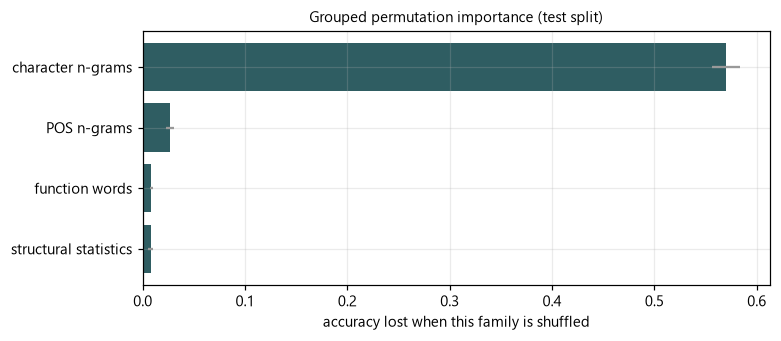

In [4]:
FAMILY_LABEL = {"fw": "function words", "st": "structural statistics",
                "ch": "character n-grams", "pos": "POS n-grams"}
fig, ax = plt.subplots(figsize=(7.2, 3.2))
d = imp.sort_values("mean_drop")
ax.barh([FAMILY_LABEL.get(f, f) for f in d["family"]], d["mean_drop"],
        xerr=d["sd_drop"], color="#2F5D62", ecolor="#999")
ax.set_xlabel("accuracy lost when this family is shuffled")
ax.set_title("Grouped permutation importance (test split)", fontsize=10)
fig.tight_layout()
fig.savefig(config.FIGURES / "permutation_importance.png", dpi=200)
fig.savefig(config.REPORT_FIGURES / "permutation_importance.png", dpi=200)
plt.show()

## 5.2 Style fingerprints

Each author's mean structural feature, in corpus standard deviations. The
`sadhu_chalit_ratio` column is the one to read first: Bangla prose of this
period is written in either the literary সাধু register (হইল, করিয়া, তাহার) or
the colloquial চলিত one (হল, করে, তার), and where an author sits on that axis
is the most interpretable single fact about their style.

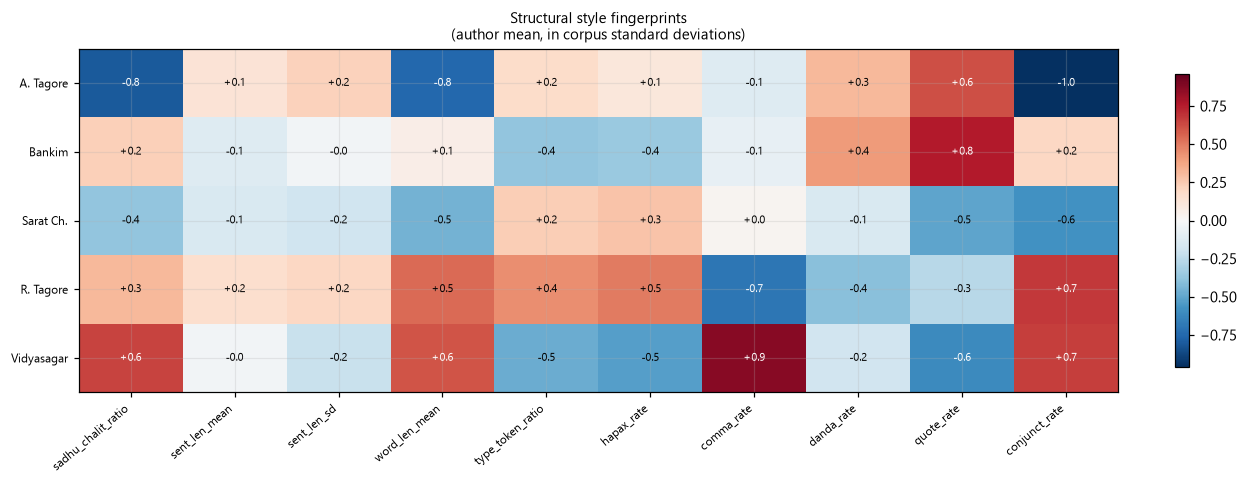

In [5]:
sig = interpret.family_signature([p.text for p in passages],
                                 [p.author for p in passages])
sig.to_csv(config.TABLES / "style_fingerprints.csv")
fig = interpret.plot_fingerprint(sig, path=config.FIGURES / "fingerprints.png")
plt.show()

The z-scored heatmap above is easiest to read at a glance; the raw units below
are what the report quotes, since "mean sentence length 18.4 tokens" is a
statement about Bangla prose and "+1.7 sd" is a statement about this corpus.

In [6]:
show = ["sadhu_rate", "chalit_rate", "sadhu_chalit_ratio", "sent_len_mean",
        "word_len_mean", "type_token_ratio", "quote_rate", "comma_rate"]

from banglastylo.stylometry import StructuralFeatures, STRUCTURAL_NAMES
S = StructuralFeatures().fit([p.text for p in passages]).transform(
    [p.text for p in passages])
raw = pd.DataFrame(S, columns=STRUCTURAL_NAMES)
raw["author"] = [p.author for p in passages]
means = raw.groupby("author")[show].mean()
means.index = [config.AUTHORS[a]["en"] for a in means.index]
means.round(3)

,sadhu_rate,chalit_rate,sadhu_chalit_ratio,sent_len_mean,word_len_mean,type_token_ratio,quote_rate,comma_rate
Abanindranath Tagore,12.695000,98.212997,0.306,18.577999,4.814,0.756,5.580,12.581000
Bankim Chandra Chattopadhyay,101.751999,21.799000,9.405,14.097000,5.258,0.725,6.223,12.875000
Sarat Chandra Chattopadhyay,121.412003,45.540001,4.079,13.789000,4.975,0.759,0.519,13.593000
Rabindranath Tagore,86.696999,25.886000,10.153,19.082001,5.521,0.771,1.608,8.787000
Ishwar Chandra Vidyasagar,135.828995,9.963000,13.131,15.898000,5.552,0.719,0.076,19.184999


## 5.3 What each author's SVM row weights

Corpus-wide, not per passage: the features whose presence most pushes a
passage *towards* each author.

In [7]:
top = interpret.top_features_per_author(pipe, top_k=10)
from banglastylo.interface import gloss
top["reads as"] = top["feature"].map(gloss)
top.to_csv(config.TABLES / "top_features_per_author.csv", index=False)

for a in sorted(top["author"].unique()):
    sub = top[(top.author == a) & (top.direction == "for")].head(8)
    print(f"\n{config.AUTHORS[a]['en']}")
    for _, r in sub.iterrows():
        print(f"   {r['weight']:+7.3f}  {r['reads as']}")


Abanindranath Tagore
    +0.078  character n-gram “তো␣”
    +0.073  character n-gram “␣তো␣”
    +0.066  character n-gram “ো␣”
    +0.065  character n-gram “লো␣”
    +0.063  POS pattern PUNCT–PUNCT
    +0.058  POS pattern PUNCT–PUNCT–NOUN
    +0.056  character n-gram “␣'”
    +0.055  POS pattern VERB–PUNCT–PUNCT

Bankim Chandra Chattopadhyay
    +0.115  character n-gram “"␣”
    +0.104  character n-gram “␣"”
    +0.092  character n-gram “ে'”
    +0.089  character n-gram “সন”
    +0.080  POS pattern VERB–PUNCT–PUNCT
    +0.078  character n-gram “;␣”
    +0.075  character n-gram “সন্”
    +0.072  POS pattern PUNCT–NOUN–PUNCT

Sarat Chandra Chattopadhyay
    +0.082  character n-gram “␣ত␣”
    +0.074  character n-gram “কহিল”
    +0.073  character n-gram “␣কহি”
    +0.073  character n-gram “␣কহ”
    +0.073  character n-gram “হিল”
    +0.072  character n-gram “কহি”
    +0.072  character n-gram “কহ”
    +0.060  character n-gram “িল,”

Rabindranath Tagore
    +0.090  character n-gram “াে”
    

## 5.4 Auditing single predictions

The two paradigms explain themselves differently, and both explanations are
shown. The discriminative one decomposes `w·x`; the generative one reports the
log-odds each character contributed to the winner over the runner-up.

In [8]:
from banglastylo.interface import Attributor, render

attributor = Attributor(svm_pipeline=pipe, generative=gen)

rng = np.random.default_rng(config.SEED)
for i in rng.choice(len(Xte), size=3, replace=False):
    print("#" * 80)
    print(f"TRUE AUTHOR: {config.AUTHORS[yte[i]]['en']}")
    print("PASSAGE:", Xte[i][:220].replace("\n", " "), "…")
    print(render(attributor.predict(Xte[i]), attributor))
    print()

################################################################################
TRUE AUTHOR: Bankim Chandra Chattopadhyay
PASSAGE: তিনি যে রঘুবংশ যৌবনে লিখিয়াছিলেন, এবং কুমারসম্ভব চল্লিশ পার করিয়া লিখিয়াছিলেন, তাহা আমি দুইটি কবিতা উদ্ধার করিয়া দেখাইতেছি- তা যাই হউক, কালিদাস বুড়া বয়সের গৌরব বুঝিলে কখনও বৃদ্ধের কপালে মুনিবৃত্তি লিখিতেন না। বিস্ম …
PREDICTED AUTHOR : Bankim Chandra Chattopadhyay  (বঙ্কিমচন্দ্র চট্টোপাধ্যায়)
passage          : 227 tokens, 18 sentences

DISCRIMINATIVE (linear SVM over stylometric features)
  predicted : Bankim Chandra Chattopadhyay
  runner-up : Ishwar Chandra Vidyasagar  (margin 0.321)
  strongest evidence overall (for Bankim Chandra Chattopadhyay over Ishwar Chandra Vidyasagar):
     +0.0491  character n-gram “তা␣”
     +0.0487  character n-gram “বন”
     +0.0438  character n-gram “সন”
     +0.0389  character n-gram “;␣”
     +0.0386  character n-gram “িলে␣”
     +0.0384  character n-gram “বলি”
  strongest evidence you can check by eye:
     +0.03

PREDICTED AUTHOR : Bankim Chandra Chattopadhyay  (বঙ্কিমচন্দ্র চট্টোপাধ্যায়)
passage          : 244 tokens, 18 sentences

DISCRIMINATIVE (linear SVM over stylometric features)
  predicted : Bankim Chandra Chattopadhyay
  runner-up : Rabindranath Tagore  (margin 0.777)
  strongest evidence overall (for Bankim Chandra Chattopadhyay over Rabindranath Tagore):
     +0.1141  character n-gram “োন␣”
     +0.1141  character n-gram “কোন␣”
     +0.0658  POS pattern X
     +0.0599  POS pattern PUNCT–CCONJ
     +0.0582  character n-gram “েখিল”
     +0.0572  character n-gram “ুষ”
  strongest evidence you can check by eye:
     +0.0658  POS pattern X   [value 0.724]
     +0.0599  POS pattern PUNCT–CCONJ   [value 0.757]
     +0.0473  function word “কোন”   [value 0.875]
     +0.0462  POS pattern NOUN–PUNCT–CCONJ   [value 0.464]
     +0.0458  POS pattern CCONJ–NOUN–ADP   [value 0.825]
     +0.0419  POS pattern PART–PUNCT   [value 0.839]
  evidence pointing the other way:
     -0.0756  character n-gram



################################################################################
TRUE AUTHOR: Bankim Chandra Chattopadhyay
PASSAGE: ইঁহারা যে প্রতারক, তাহার বিশেষ প্রমাণ এই যে, ইঁহারা অর্থাদির কামনা করেন না। ৫। এই ষড়্বিধ উপায়ের দ্বারা উদরপূর্ত্তি বা পুরুষার্থ অসাধ্য। এই সূত্রের দ্বারা পূর্ব্বপণ্ডিতদিগের মত খণ্ডন করা যাইতেছে। বিদ্যাদি ষড়্বিধ উপায়ে …
PREDICTED AUTHOR : Bankim Chandra Chattopadhyay  (বঙ্কিমচন্দ্র চট্টোপাধ্যায়)
passage          : 245 tokens, 30 sentences

DISCRIMINATIVE (linear SVM over stylometric features)
  predicted : Bankim Chandra Chattopadhyay
  runner-up : Rabindranath Tagore  (margin 0.243)
  strongest evidence overall (for Bankim Chandra Chattopadhyay over Rabindranath Tagore):
     +0.0835  POS pattern PUNCT–NOUN–PUNCT
     +0.0767  character n-gram “␣"”
     +0.0636  POS pattern PUNCT–PUNCT
     +0.0619  character n-gram “িম”
     +0.0558  POS pattern PUNCT–CCONJ
     +0.0521  character n-gram “র্ত্”
  strongest evidence you can check by eye:
     +0.083

### A worked example in the proposal's own format

The proposal walks through one constructed sentence. Here is the same shape of
output, produced by the real system.

In [9]:
from banglastylo.interface import DEMO_PASSAGE
print(render(attributor.predict(DEMO_PASSAGE), attributor))

PREDICTED AUTHOR : Rabindranath Tagore  (রবীন্দ্রনাথ ঠাকুর)
passage          : 26 tokens, 2 sentences
  ! short passage — stylometric estimates are noisy below ~80 tokens

DISCRIMINATIVE (linear SVM over stylometric features)
  predicted : Rabindranath Tagore
  runner-up : Sarat Chandra Chattopadhyay  (margin 0.386)
  strongest evidence overall (for Rabindranath Tagore over Sarat Chandra Chattopadhyay):
     +0.0940  character n-gram “হা␣”
     +0.0824  character n-gram “াহা␣”
     +0.0810  character n-gram “াহ”
     +0.0742  character n-gram “াইয়”
     +0.0674  character n-gram “াইয”
     +0.0592  character n-gram “িব”
  strongest evidence you can check by eye:
     +0.0513  POS pattern PRON–PART   [value 1.894]
     +0.0418  POS pattern ADP–VERB–NOUN   [value 1.012]
     +0.0374  function word “তাহা”   [value 1.101]
     +0.0314  function word “যাহা”   [value 1.708]
     +0.0297  POS pattern VERB–NOUN–NOUN   [value 0.632]
     +0.0261  POS pattern VERB   [value 1.239]
  evidence poi

## 5.5 Where the model fails, and why

Errors are more informative than successes. These are the test passages the
model got wrong with the *highest* confidence — the ones whose style genuinely
points the wrong way.

In [10]:
scores = pipe.decision_function(Xte)
pred = pipe.predict(Xte)
classes = list(pipe.named_steps["clf"].classes_)
margin = np.sort(scores, axis=1)[:, -1] - np.sort(scores, axis=1)[:, -2]

wrong = np.where(pred != np.asarray(yte))[0]
wrong = wrong[np.argsort(-margin[wrong])][:4]
for i in wrong:
    print("=" * 82)
    print(f"true: {config.AUTHORS[yte[i]]['en']:32s} "
          f"predicted: {config.AUTHORS[pred[i]]['en']}  (margin {margin[i]:.2f})")
    print(Xte[i][:260].replace("\n", " "), "…")
    exp = interpret.linear_contributions(pipe, Xte[i], top_k=6)
    for f, c, v in exp["for_prediction"]:
        print(f"    {c:+7.3f}  {gloss(f)}")
print("=" * 82)

true: Rabindranath Tagore              predicted: Ishwar Chandra Vidyasagar  (margin 1.71)
পুরোচননামা এক দুর্ম্মতি সচিবকে আহ্বান করিয়া দুর্য্যোধন তাহাকে কহিতে লাগিলেন- হে পুরোচন! পাণ্ডবগণ পাশুপত-উৎসবে বিহারার্থ বারণাবৎ নগরে গমন করিবেন। তুমি দ্রুতগামী অশ্বতরযোজিত রথে অদ্যই তথায় গমন কর। নগরের প্রান্তদেশে শন সর্জ্জরস জতুকাষ্ঠ প্রভৃতি যাবতীয় অগ্নিভোজ …
     +0.099  character n-gram “ৎক”
     +0.068  character n-gram “স␣”
     +0.067  character n-gram “ও␣”
     +0.060  character n-gram “␣ও␣”
     +0.057  character n-gram “␣ও”
     +0.057  POS pattern NUM–NOUN–NOUN
true: Rabindranath Tagore              predicted: Ishwar Chandra Vidyasagar  (margin 1.35)
যাঁহার সমান যােদ্ধা মনুষ্যলােকে বিদ্যমান নাই, তুমি কি করিয়া সেই কুরুকুলাগ্রগণ্য ভীষ্মের সহিত সংগ্রাম করিলে? সর্ব্বশাস্ত্রবিশারদ যাদব ও কৌরবগুরু আচার্য্য দ্রোণের অস্ত্রকৌশল বা তুমি কি প্রকারে সহ্য করিলে? কি আর বলিব, তুমি হৃত-গােধন প্রত্যাহরণ করিয়া অতি মহৎ কার …
     +0.065  character n-gram “্তর␣”
     +0.062  POS pattern VERB–PUNCT–ADJ


## 5.6 How much text does the system actually need?

Accuracy as a function of passage length. The practical question a user of the
interface will ask — how long does my passage have to be before the answer
means anything?

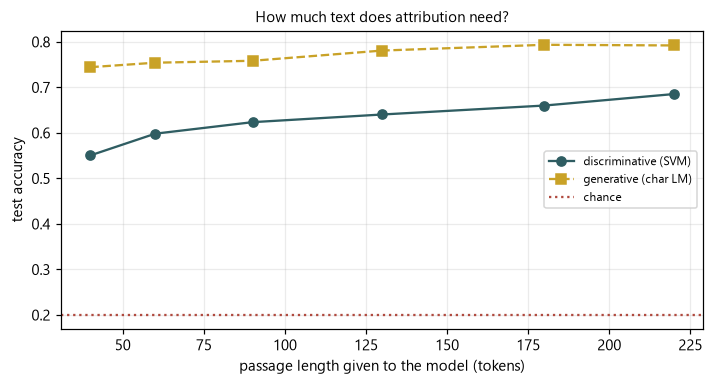

,tokens,discriminative,generative
0,40,0.550562,0.744382
1,60,0.598315,0.754213
2,90,0.623596,0.758427
3,130,0.640449,0.780899
4,180,0.660112,0.793539
5,220,0.685393,0.792135


In [11]:
from sklearn.metrics import accuracy_score
from banglastylo.normalize import word_tokenize

lengths = [40, 60, 90, 130, 180, 220]
rows = []
for L in lengths:
    trunc = [" ".join(word_tokenize(t)[:L]) for t in Xte]
    rows.append({
        "tokens": L,
        "discriminative": accuracy_score(yte, pipe.predict(trunc)),
        "generative": accuracy_score(yte, gen.predict(trunc)),
    })
curve = pd.DataFrame(rows)
curve.to_csv(config.TABLES / "length_curve.csv", index=False)

fig, ax = plt.subplots(figsize=(6.6, 3.6))
ax.plot(curve["tokens"], curve["discriminative"], "o-",
        color="#2F5D62", label="discriminative (SVM)")
ax.plot(curve["tokens"], curve["generative"], "s--",
        color="#C9A227", label="generative (char LM)")
ax.axhline(1/len(set(yte)), ls=":", color="#B04A3F", label="chance")
ax.set_xlabel("passage length given to the model (tokens)")
ax.set_ylabel("test accuracy")
ax.set_title("How much text does attribution need?", fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(config.FIGURES / "length_curve.png", dpi=200)
fig.savefig(config.REPORT_FIGURES / "length_curve.png", dpi=200)
plt.show()
curve